# 04 — Final model: deep_9 no-morph

The final model of the project, the best of the nine deep-learning iterations described in
`03_deep_learning_journey.ipynb`:

- **Preprocessing**: offline HSV-based white-cell crop, then CLAHE on the HSV value channel.
- **Model**: ConvNeXt-Base (ImageNet) → SE-style channel-attention gate → 3-layer MLP head.
- **Training**: two phases (5 epochs with a frozen backbone, then full fine-tuning), Focal loss
  with label smoothing, Mixup/CutMix (skipped for batches containing rare classes, which in practice
  leaves them active on only ~1 % of the batches),
  class-balanced sampling, mixed precision, early stopping on validation macro-F1.
- **Inference**: test-time augmentation (one plain pass + 8 random flip/rotation passes).

This notebook rebuilds the whole pipeline from `src/`, loads the trained weights
(`models/best_model.pt`), evaluates them on the leakage-free validation split and writes the
test-set submission. Training takes about 70 minutes on one RTX 3090; set `RETRAIN = True`
below to retrain from scratch (the new weights are saved to a separate file).

In [1]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_recall_fscore_support)
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, WeightedRandomSampler

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src.deep_dataset import (SEED, WBCDataset, build_oversampled_dataset,
                              leakage_free_split, run_precrop_pipeline, seed_worker,
                              train_aug, val_aug)
from src.deep_train import WBCClassifier, predict, predict_tta, train_model_2phase

DATA, MODELS, RESULTS = ROOT / "data", ROOT / "models", ROOT / "results" / "deep_9_no_morph"
RESULTS.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

Device: cuda NVIDIA GeForce RTX 3090


## 1. Data: oversampling and cropping

Classes below the median class size (415 images) are oversampled offline with lightly
augmented copies, then every image is cropped around the white cell with an HSV nucleus
score. Both steps run once and are skipped when their outputs already exist in `data/`.

In [2]:
train_df = pd.read_csv(DATA / "train_metadata.csv")
test_df = pd.read_csv(DATA / "test_metadata.csv")

class_counts = train_df['label'].value_counts()
rare_threshold = int(class_counts.median())
rare_classes = [c for c, n in class_counts.items() if n < rare_threshold]
print(f"Rare classes (< {rare_threshold} images): {rare_classes}")

train_df_aug = build_oversampled_dataset(
    train_df, DATA / "train", DATA / "train_oversampled",
    DATA / "train_oversampled_metadata.csv", rare_classes, rare_threshold)
run_precrop_pipeline(DATA / "train_oversampled", DATA / "train_precropped",
                     DATA / "test_precropped", train_df_aug, test_df, DATA / "test",
                     DATA / ".precrop_done")

print(f"\nTraining images after oversampling: {len(train_df_aug):,} (was {len(train_df):,})")
print(pd.DataFrame({'original': class_counts,
                    'oversampled': train_df_aug['label'].value_counts()}).to_string())

Rare classes (< 415 images): ['BNE', 'VLY', 'MMY', 'PMY', 'PC', 'PLY']
Oversampled dataset already exists: train_oversampled_metadata.csv
Pre-cropped images already exist.

Training images after oversampling: 30,081 (was 28,901)
       original  oversampled
label                       
BA          415          415
BL         2012         2012
BNE         391          415
EO          861          861
LY         8101         8101
MMY         360          415
MO         2746         2746
MY          441          441
PC           68          415
PLY          11          415
PMY         114          415
SNE       13015        13015
VLY         366          415


## 2. Leakage-free validation split

A stratified 90/10 split is made on the **original** images; augmented copies of training images
stay in the training set, those of validation images (109) are discarded, and the validation
set contains original images only. (Splitting after oversampling,
as in deep_5, put copies of validation images in the training set and inflated the validation
macro-F1 from 0.70 to 0.82.)

In [3]:
le = LabelEncoder().fit(train_df['label'])
train_fold_df, val_fold_df = leakage_free_split(train_df, train_df_aug, le, val_ratio=0.10)
print(f"Train: {len(train_fold_df):,} images (originals + augmented copies)")
print(f"Val:   {len(val_fold_df):,} images (originals only, no shared parent with train)")

Train: 27,081 images (originals + augmented copies)
Val:   2,891 images (originals only, no shared parent with train)


## 3. Model and training

With `RETRAIN = False` (default) the trained weights of the original run are loaded. The
training curves below come from that run's log (`results/deep_9_no_morph/history.json`).

In [4]:
RETRAIN = False
CONFIG = dict(batch_size=16, accum_steps=4, num_epochs=60, warmup_epochs=5, patience=10,
              head_lr=3e-4, finetune_bb_lr=1e-4, finetune_head_lr=1e-4, weight_decay=1e-4,
              label_smoothing=0.05, focal_gamma=2.0, mixup_alpha=0.2, cutmix_alpha=1.0,
              cutmix_prob=0.5, dropout=0.3)

model = WBCClassifier(num_classes=len(le.classes_), dropout=CONFIG['dropout'],
                      pretrained=RETRAIN)
for part, n in model.parameter_counts().items():
    print(f"{part:>15s}: {n:>11,} parameters")

if RETRAIN:
    train_ds = WBCDataset(train_fold_df, DATA / "train_precropped", le, train_aug)
    counts = np.bincount(train_ds.labels, minlength=len(le.classes_)).astype(np.float64)
    sampler = WeightedRandomSampler(torch.tensor((counts ** -0.5)[train_ds.labels]),
                                    num_samples=len(train_ds), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler,
                              num_workers=4, pin_memory=True, drop_last=True,
                              worker_init_fn=seed_worker)
    val_loader = DataLoader(WBCDataset(val_fold_df, DATA / "train_precropped", le, val_aug),
                            batch_size=CONFIG['batch_size'], num_workers=4, pin_memory=True)
    train_kwargs = {k: v for k, v in CONFIG.items() if k not in ('batch_size', 'dropout')}
    model, history = train_model_2phase(
        model.to(device), train_loader, val_loader, device=device,
        checkpoint_path=MODELS / "deep_9_no_morph_retrained.pt",
        rare_class_ids=set(le.transform(rare_classes)), **train_kwargs)
else:
    ckpt = torch.load(MODELS / "best_model.pt", map_location="cpu")
    model.load_state_dict(ckpt['model_state_dict'])
    history = json.loads((RESULTS / "history.json").read_text())
    print(f"\nLoaded models/best_model.pt (epoch {ckpt['epoch']}, "
          f"val macro-F1 {ckpt['val_f1']:.4f})")

       backbone:  87,564,416 parameters
 attention_gate:     263,296 parameters
   morph_branch:           0 parameters
           head:     659,469 parameters
          total:  88,487,181 parameters



Loaded models/best_model.pt (epoch 21, val macro-F1 0.7052)


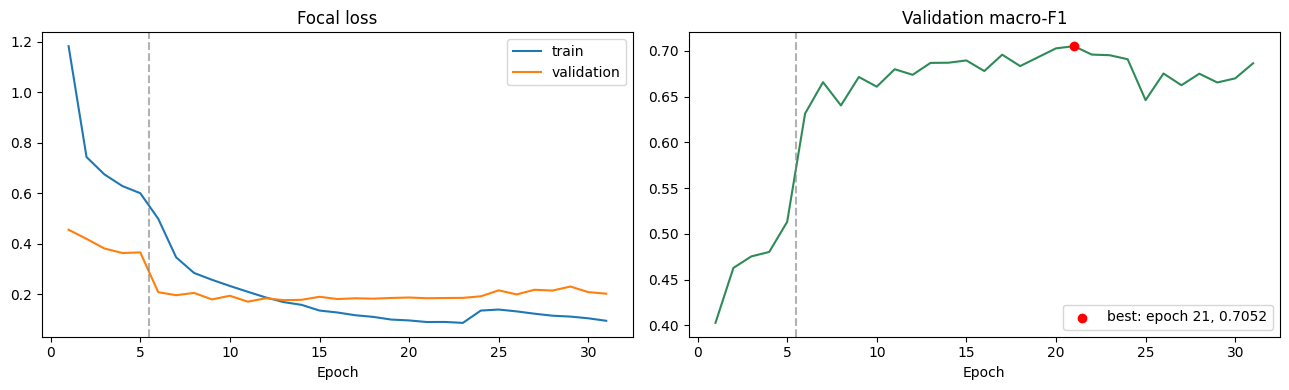

In [5]:
epochs = np.arange(1, len(history['val_f1']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'], label='validation')
axes[0].set_title("Focal loss")
axes[0].legend()
axes[1].plot(epochs, history['val_f1'], color='seagreen')
best = int(np.argmax(history['val_f1']))
axes[1].scatter(epochs[best], history['val_f1'][best], color='red', zorder=3,
                label=f"best: epoch {epochs[best]}, {history['val_f1'][best]:.4f}")
axes[1].set_title("Validation macro-F1")
axes[1].legend()
for ax in axes:
    ax.axvline(CONFIG['warmup_epochs'] + 0.5, color='gray', linestyle='--', alpha=0.6)
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

The dashed line marks the end of the frozen-backbone phase: unfreezing ConvNeXt lifts the
validation macro-F1 from 0.51 to 0.63 in one epoch. The cosine schedule restarts after epoch 23
(`history.json` logs the learning rate after each epoch's scheduler step), after which the validation score no longer improves and early stopping ends training at
epoch 31.

## 4. Validation results

In [6]:
val_ds = WBCDataset(val_fold_df, DATA / "train_precropped", le, val_aug)
val_logits, val_features = predict(model, val_ds, device)
val_pred = val_logits.argmax(1).numpy()
y_val = val_ds.labels

val_f1 = f1_score(y_val, val_pred, average='macro')
val_acc = accuracy_score(y_val, val_pred)
print(f"Validation macro-F1: {val_f1:.4f}   accuracy: {val_acc:.4f}   (n = {len(y_val):,})\n")
print(classification_report(y_val, val_pred, target_names=le.classes_, digits=3,
                            zero_division=0))

Validation macro-F1: 0.7052   accuracy: 0.9367   (n = 2,891)

              precision    recall  f1-score   support

          BA      0.975     0.929     0.951        42
          BL      0.902     0.915     0.909       201
         BNE      0.413     0.487     0.447        39
          EO      0.977     0.988     0.983        86
          LY      0.948     0.959     0.953       810
         MMY      0.731     0.528     0.613        36
          MO      0.904     0.891     0.897       275
          MY      0.694     0.773     0.731        44
          PC      0.750     0.429     0.545         7
         PLY      0.000     0.000     0.000         1
         PMY      0.545     0.545     0.545        11
         SNE      0.982     0.979     0.981      1302
         VLY      0.629     0.595     0.611        37

    accuracy                          0.937      2891
   macro avg      0.727     0.694     0.705      2891
weighted avg      0.937     0.937     0.936      2891



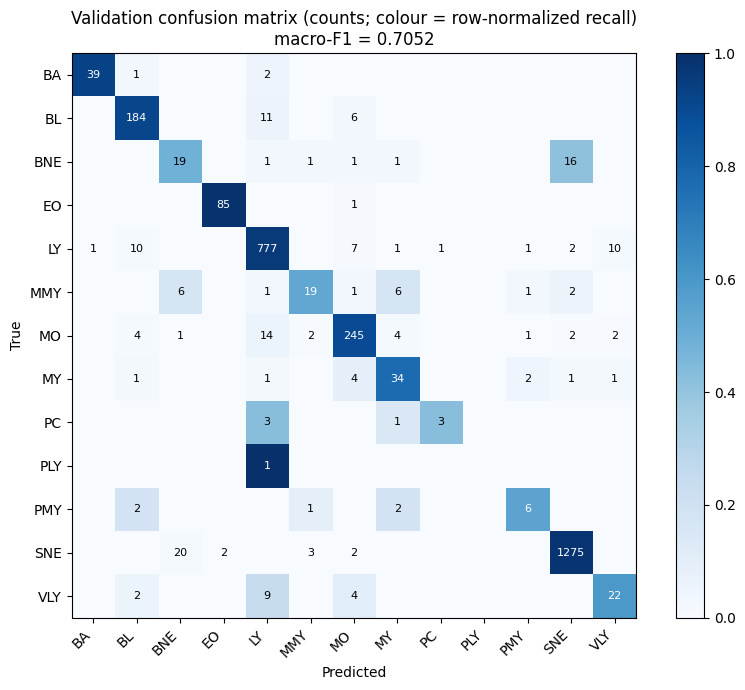

Most frequent confusions (true -> predicted):
   SNE -> BNE   20 images (1.5% of true SNE)
   BNE -> SNE   16 images (41.0% of true BNE)
    MO -> LY    14 images (5.1% of true MO)
    BL -> LY    11 images (5.5% of true BL)
    LY -> VLY   10 images (1.2% of true LY)
    LY -> BL    10 images (1.2% of true LY)
   VLY -> LY     9 images (24.3% of true VLY)
    LY -> MO     7 images (0.9% of true LY)


In [7]:
cm = confusion_matrix(y_val, val_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(le.classes_)), le.classes_, rotation=45, ha='right')
ax.set_yticks(range(len(le.classes_)), le.classes_)
for i in range(len(cm)):
    for j in range(len(cm)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                    color='white' if cm_norm[i, j] > 0.5 else 'black')
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Validation confusion matrix (counts; colour = row-normalized recall)\n"
             f"macro-F1 = {val_f1:.4f}")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(RESULTS / "confusion_matrix.png", dpi=120)
plt.show()

pairs = [(cm[i, j], le.classes_[i], le.classes_[j], cm_norm[i, j])
         for i in range(len(cm)) for j in range(len(cm)) if i != j and cm[i, j]]
print("Most frequent confusions (true -> predicted):")
for n, t, p, r in sorted(pairs, reverse=True)[:8]:
    print(f"  {t:>4s} -> {p:<4s} {n:3d} images ({r:.1%} of true {t})")

Performance is very high on the frequent classes (SNE, LY, EO, BA, BL > 0.90 F1) and limited by
a few visually close pairs: band vs segmented neutrophils (BNE/SNE), variant vs normal
lymphocytes (VLY/LY) and the myeloid maturation stages (MMY/MY/PMY). PLY has a single
validation image, so its F1 is either 0 or 1.

## 5. Backbone features + Random Forest (hybrid baseline)

The original pipeline also fits a Random Forest on the gated backbone features and keeps
whichever of the two classifiers scores higher on validation. (The original run extracted the
training features with training-time augmentation and obtained 0.6801; here they are extracted
from the non-augmented images.)

In [8]:
train_eval_ds = WBCDataset(train_fold_df, DATA / "train_precropped", le, val_aug)
_, train_features = predict(model, train_eval_ds, device)
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight='balanced',
                            n_jobs=-1, random_state=SEED)
rf.fit(train_features.numpy(), train_eval_ds.labels)
rf_f1 = f1_score(y_val, rf.predict(val_features.numpy()), average='macro')
print(f"Features + Random Forest: val macro-F1 = {rf_f1:.4f}")
print(f"ConvNeXt head:            val macro-F1 = {val_f1:.4f}  -> the network head is kept")

Features + Random Forest: val macro-F1 = 0.6873
ConvNeXt head:            val macro-F1 = 0.7052  -> the network head is kept


## 6. Test-set prediction

Logits are averaged over one plain pass and 8 random flip/rotation passes.

In [9]:
seed_everything()
test_logits = predict_tta(model, test_df, DATA / "test_precropped", device)
submission = pd.DataFrame({'ID': test_df['ID'],
                           'label': le.inverse_transform(test_logits.argmax(1).numpy())})
submission.to_csv(ROOT / "results" / "submission.csv", index=False)
print(f"Saved results/submission.csv: {len(submission):,} rows")
print(submission['label'].value_counts().to_string())

  TTA round 1/8 done


  TTA round 2/8 done


  TTA round 3/8 done


  TTA round 4/8 done


  TTA round 5/8 done


  TTA round 6/8 done


  TTA round 7/8 done


  TTA round 8/8 done
Saved results/submission.csv: 9,634 rows
label
SNE    4310
LY     2715
MO      900
BL      685
EO      293
MY      168
BNE     162
BA      141
MMY     108
VLY     100
PMY      37
PC       13
PLY       2


In [10]:
_, _, _, support = precision_recall_fscore_support(y_val, val_pred, zero_division=0)
summary = {
    'model': 'deep_9 no-morph: ConvNeXt-Base + SE-style attention gate + MLP head, HSV-V CLAHE',
    'checkpoint': ('models/deep_9_no_morph_retrained.pt' if RETRAIN else 'models/best_model.pt'),
    'checkpoint_epoch': None if RETRAIN else ckpt['epoch'],
    'val_n': int(len(y_val)),
    'val_macro_f1': round(float(val_f1), 4),
    'val_accuracy': round(float(val_acc), 4),
    'hybrid_features_rf_macro_f1': round(float(rf_f1), 4),
    'per_class_f1': dict(zip(le.classes_, np.round(f1_score(y_val, val_pred, average=None), 4).tolist())),
    'per_class_support': dict(zip(le.classes_, support.tolist())),
    'test_prediction_counts': submission['label'].value_counts().to_dict(),
}
(RESULTS / "summary.json").write_text(json.dumps(summary, indent=2))
np.save(RESULTS / "confusion_matrix.npy", cm)
print(json.dumps({k: summary[k] for k in ('val_macro_f1', 'val_accuracy',
                                          'hybrid_features_rf_macro_f1')}, indent=2))

{
  "val_macro_f1": 0.7052,
  "val_accuracy": 0.9367,
  "hybrid_features_rf_macro_f1": 0.6873
}


## Conclusion

The final model reaches a validation macro-F1 of 0.705 with 93.7 % accuracy on 2,891
held-out original images. This split is also used for early stopping, so the score is somewhat
optimistic. Compared with deep_6 (0.699, same backbone without the attention gate and the CLAHE
step), the difference is within the noise of the split; most of the remaining
error is concentrated in a handful of rare, morphologically close classes, which is where
more labelled data would help most.